In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

import os

os.makedirs("../reports/charts", exist_ok=True)

In [16]:
df = pd.read_csv("../data/raw/all_schemes_nav.csv")

df.head()

,scheme_code,scheme_name,fund_house,date,nav
0,125497,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,2026-06-19,202.0761
1,125497,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,2026-06-18,200.9565
2,125497,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,2026-06-17,199.8302
3,125497,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,2026-06-16,198.6152
4,125497,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,2026-06-15,198.0320


In [21]:
df["date"] = pd.to_datetime(df["date"])

df["nav"] = pd.to_numeric(df["nav"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19882 entries, 0 to 19881
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   scheme_code  19882 non-null  int64         
 1   scheme_name  19882 non-null  str           
 2   fund_house   19882 non-null  str           
 3   date         19882 non-null  datetime64[us]
 4   nav          19882 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 776.8 KB


In [22]:
import plotly.express as px

fig = px.line(
    df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes"
)

fig.show()

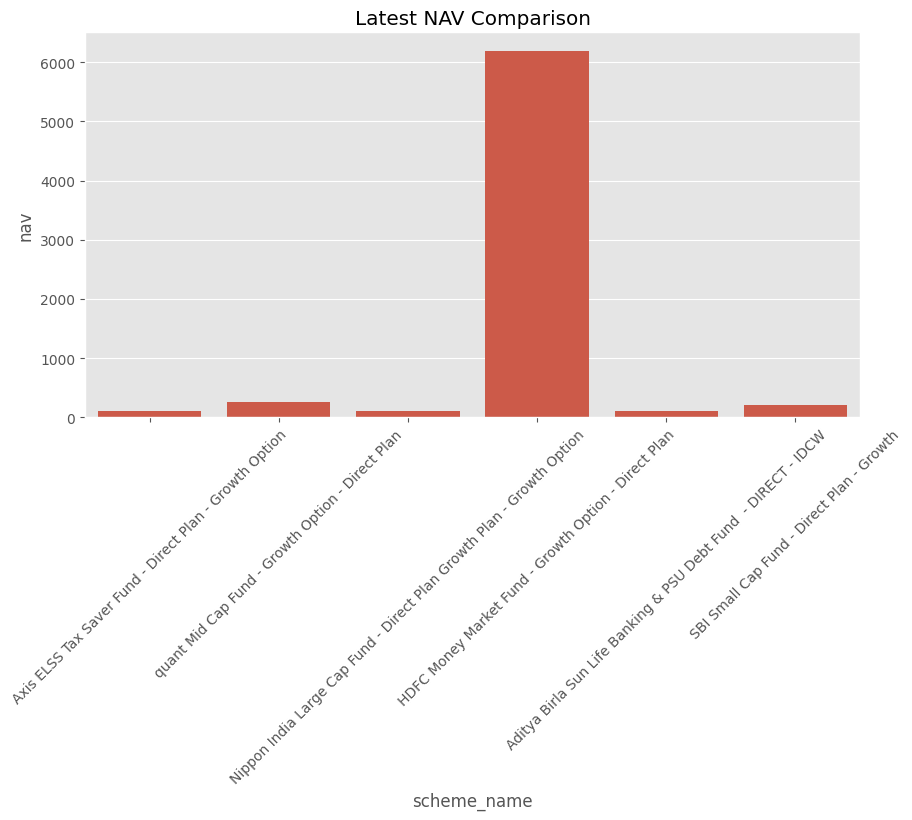

In [23]:
latest = df.sort_values("date").groupby("scheme_name").tail(1)

plt.figure(figsize=(10,5))

sns.barplot(
    data=latest,
    x="scheme_name",
    y="nav"
)

plt.xticks(rotation=45)

plt.title("Latest NAV Comparison")

plt.show()

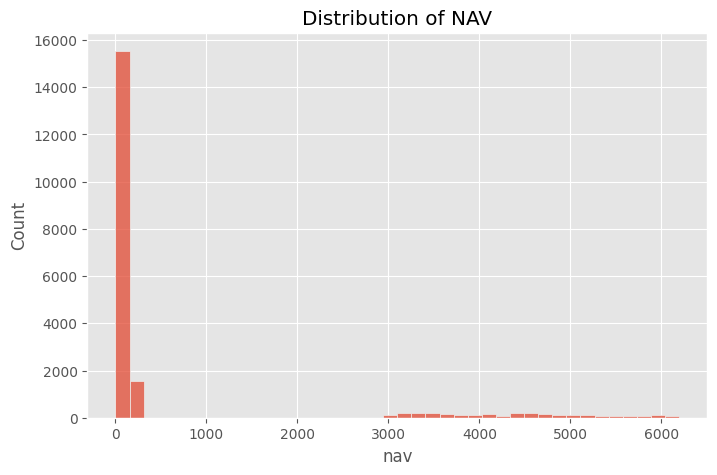

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["nav"], bins=40)

plt.title("Distribution of NAV")

plt.show()

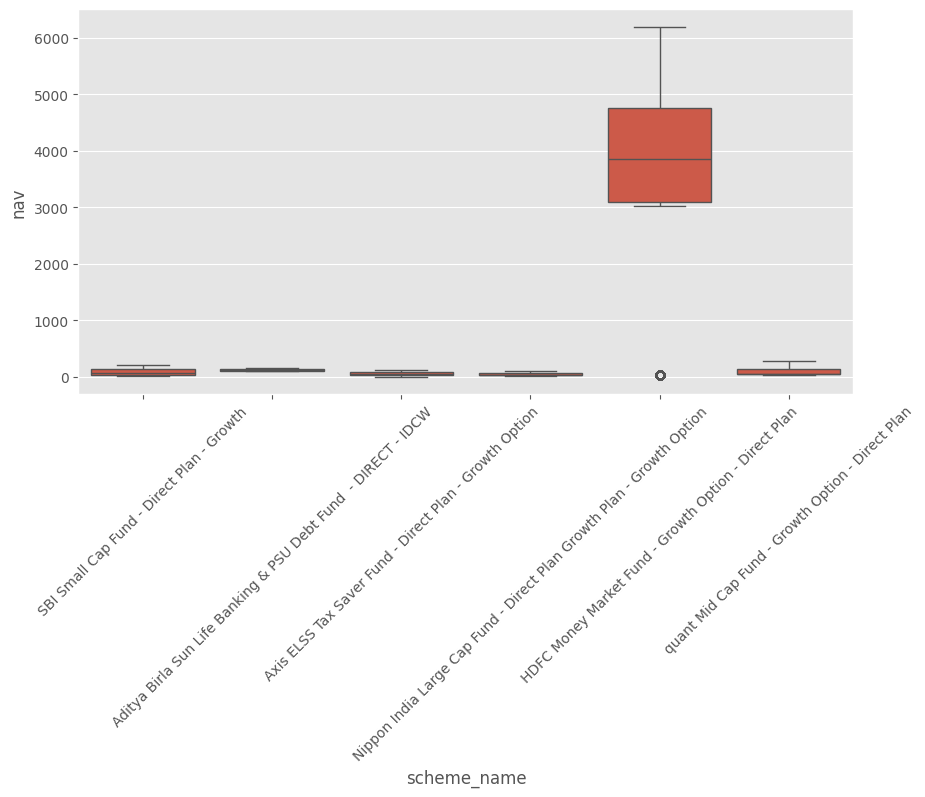

In [25]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="scheme_name",
    y="nav"
)

plt.xticks(rotation=45)

plt.show()

In [26]:
monthly = df.copy()

monthly["month"] = monthly["date"].dt.to_period("M")

monthly = (
    monthly
    .groupby(["month","scheme_name"])["nav"]
    .mean()
    .reset_index()
)

monthly["month"] = monthly["month"].astype(str)

fig = px.line(
    monthly,
    x="month",
    y="nav",
    color="scheme_name",
    title="Monthly Average NAV"
)

fig.show()

In [27]:
yearly = df.copy()

yearly["year"] = yearly["date"].dt.year

yearly = (
    yearly
    .groupby(["year","scheme_name"])["nav"]
    .mean()
    .reset_index()
)

fig = px.bar(
    yearly,
    x="year",
    y="nav",
    color="scheme_name",
    barmode="group",
    title="Yearly Average NAV"
)

fig.show()

In [28]:
df = df.sort_values(["scheme_name","date"])

df["daily_return"] = (
    df
    .groupby("scheme_name")["nav"]
    .pct_change()
)

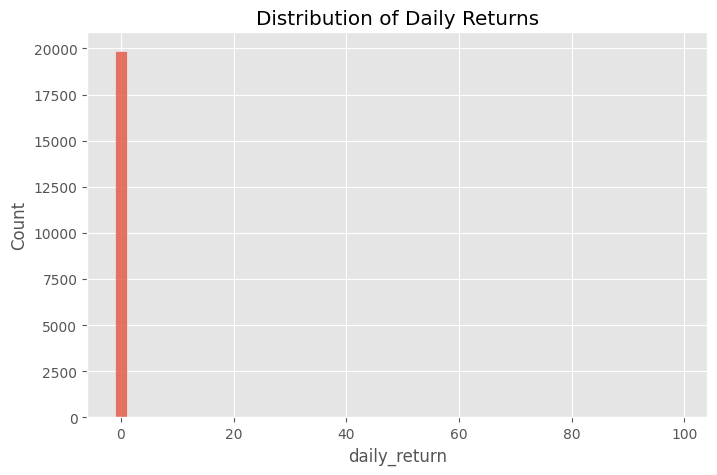

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.show()

In [30]:
df["rolling30"] = (
    df.groupby("scheme_name")["nav"]
      .transform(lambda x: x.rolling(30).mean())
)

fig = px.line(
    df,
    x="date",
    y="rolling30",
    color="scheme_name",
    title="30-Day Rolling Average NAV"
)

fig.show()

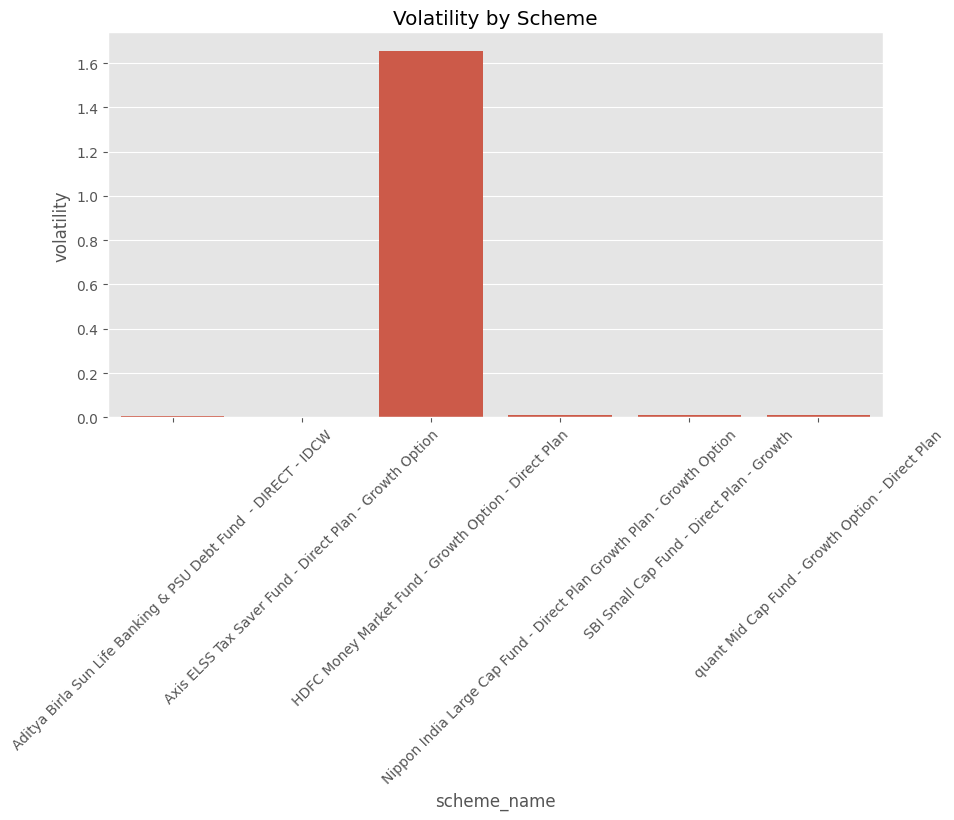

In [31]:
volatility = (
    df.groupby("scheme_name")["daily_return"]
      .std()
      .reset_index(name="volatility")
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=volatility,
    x="scheme_name",
    y="volatility"
)

plt.xticks(rotation=45)

plt.title("Volatility by Scheme")

plt.show()

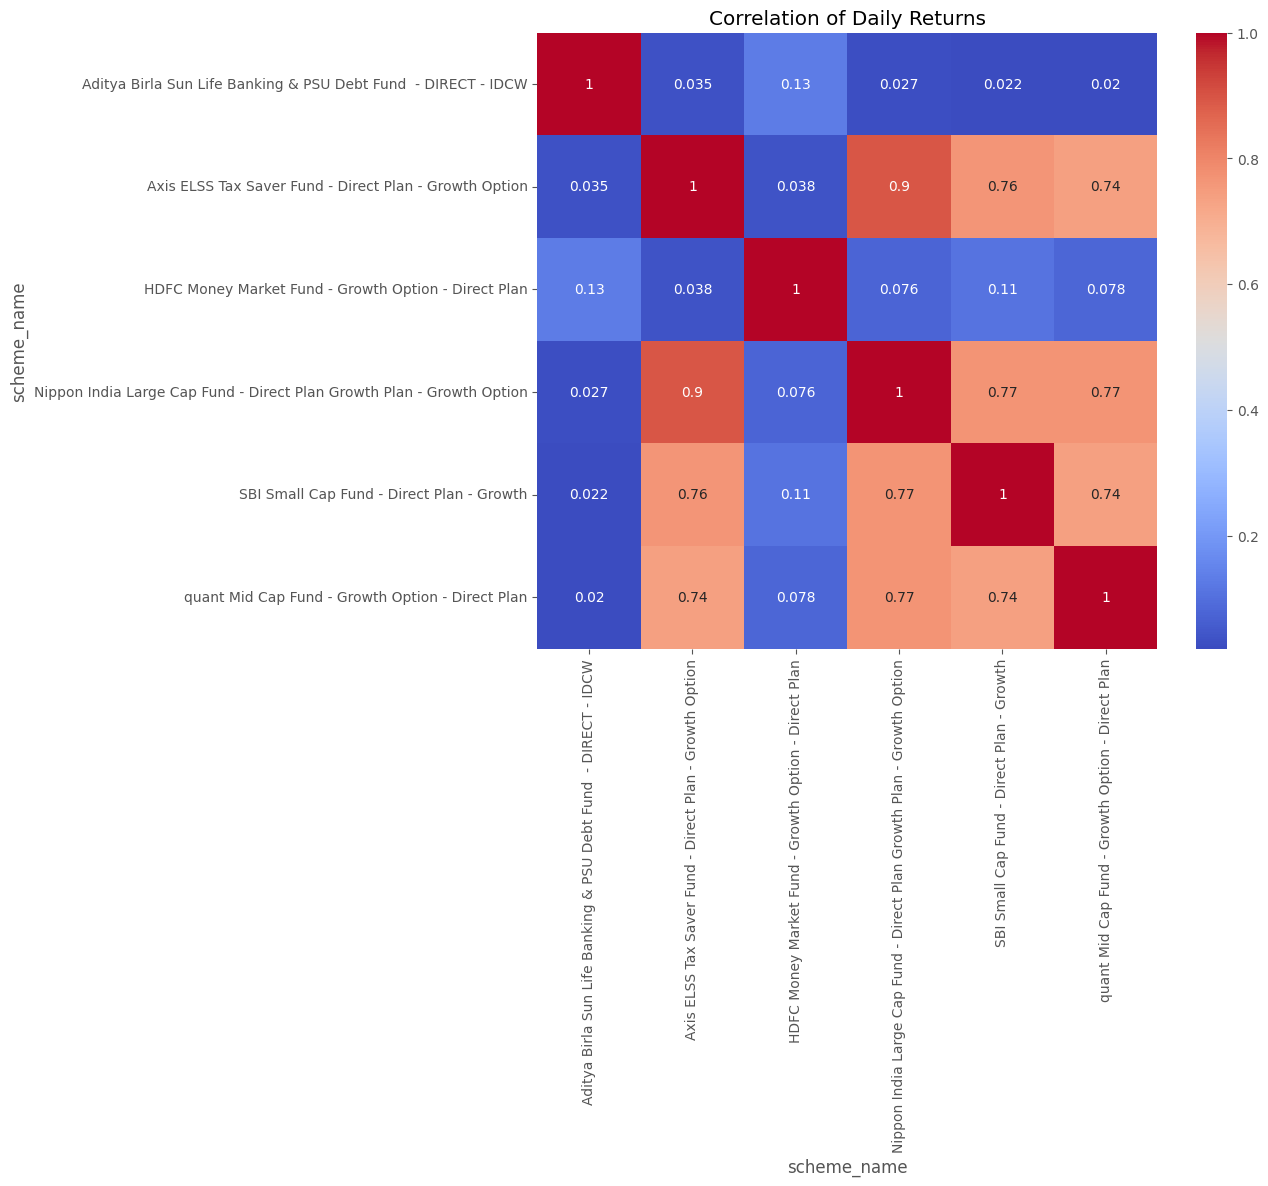

In [32]:
pivot = df.pivot_table(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Daily Returns")

plt.show()

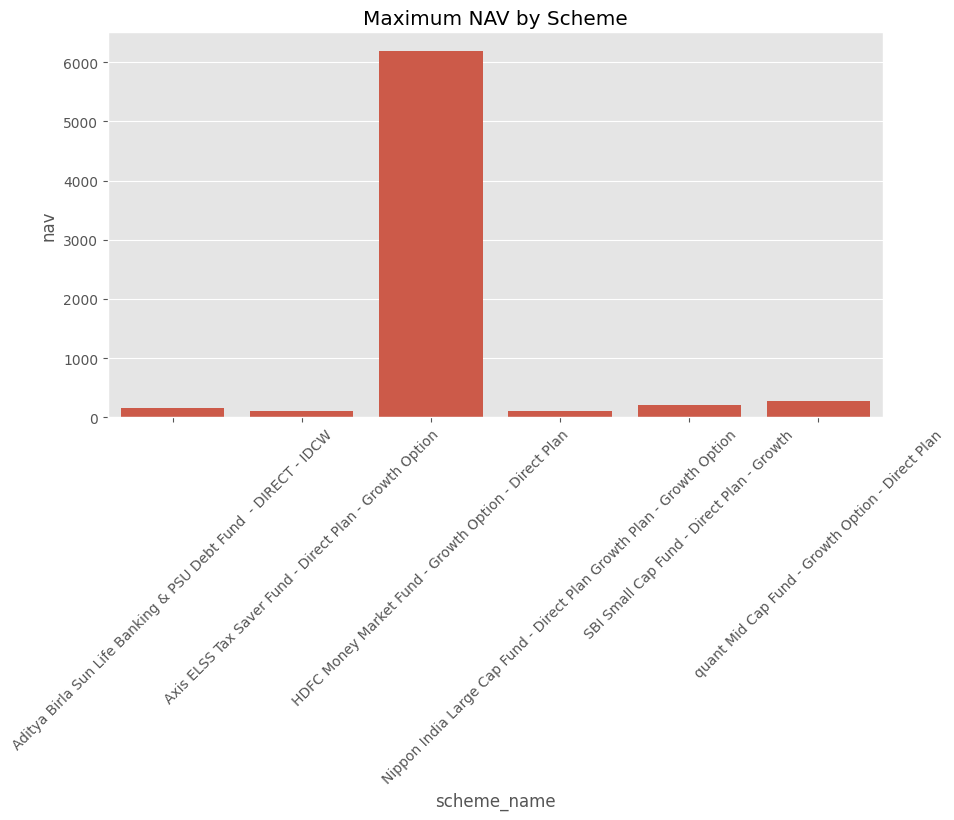

In [33]:
maximum = (
    df.groupby("scheme_name")["nav"]
      .max()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=maximum,
    x="scheme_name",
    y="nav"
)

plt.xticks(rotation=45)

plt.title("Maximum NAV by Scheme")

plt.show()

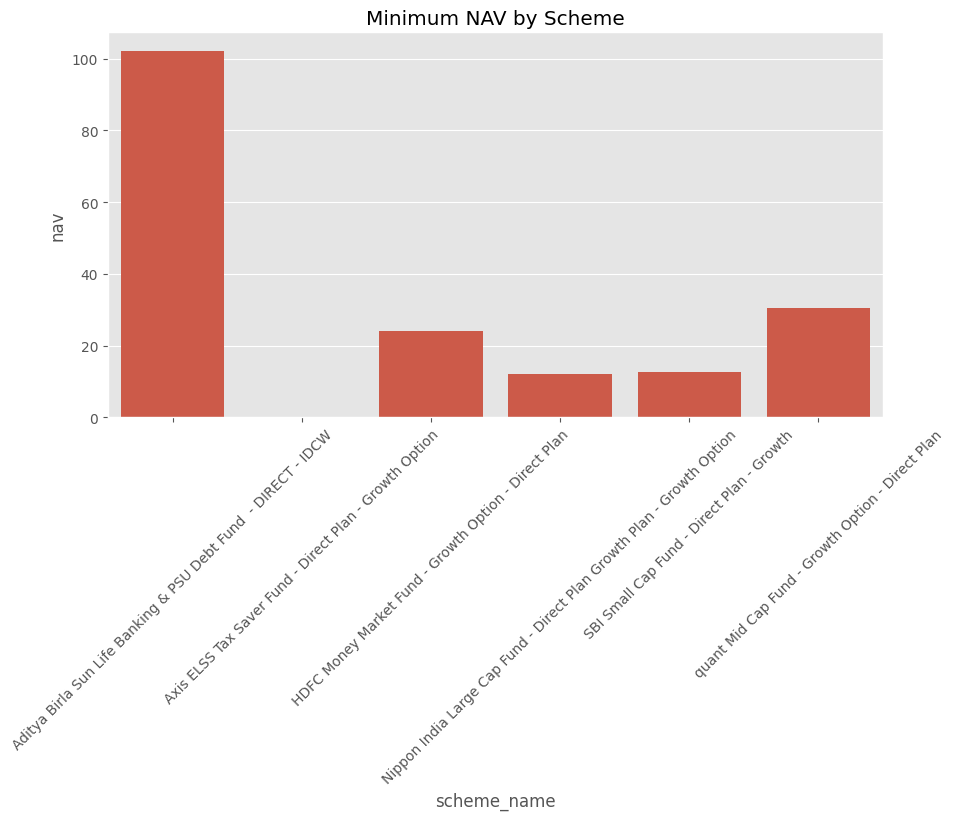

In [34]:
minimum = (
    df.groupby("scheme_name")["nav"]
      .min()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=minimum,
    x="scheme_name",
    y="nav"
)

plt.xticks(rotation=45)

plt.title("Minimum NAV by Scheme")

plt.show()

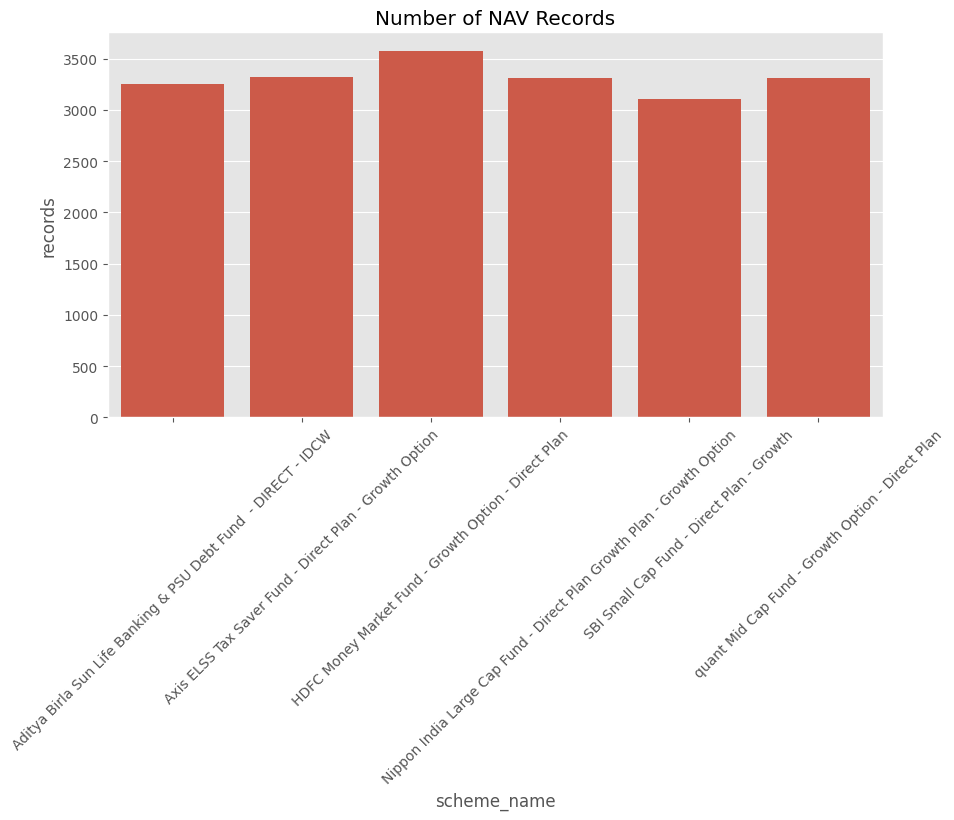

In [35]:
records = (
    df.groupby("scheme_name")
      .size()
      .reset_index(name="records")
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=records,
    x="scheme_name",
    y="records"
)

plt.xticks(rotation=45)

plt.title("Number of NAV Records")

plt.show()

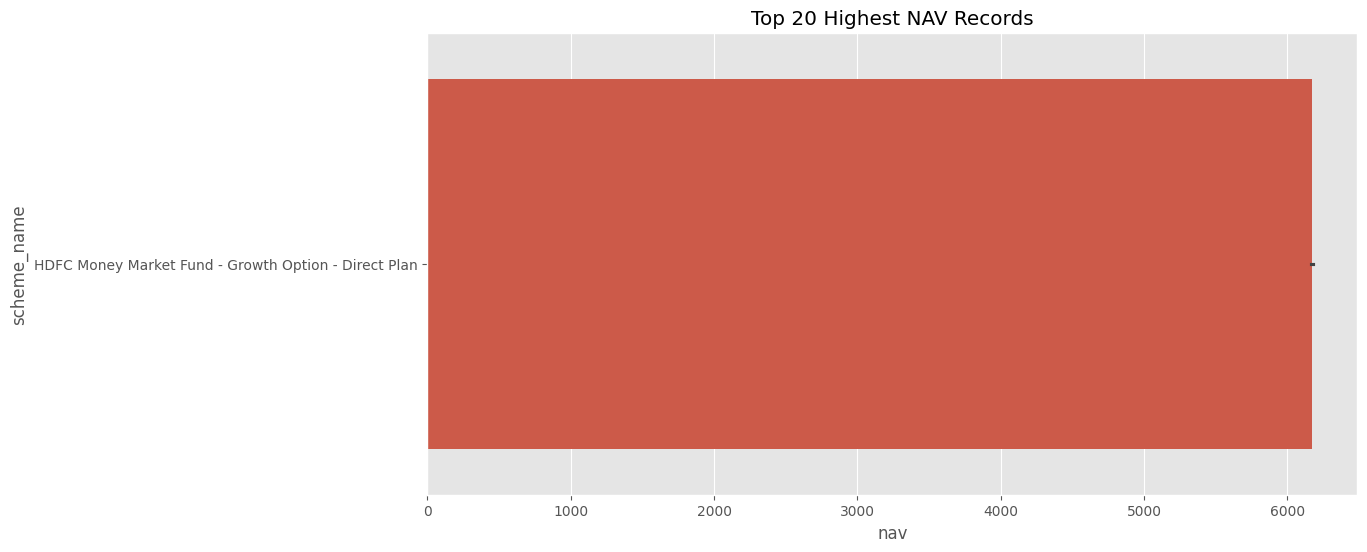

In [36]:
top_nav = (
    df.nlargest(20, "nav")
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_nav,
    x="nav",
    y="scheme_name"
)

plt.title("Top 20 Highest NAV Records")

plt.show()